In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional


In [ ]:

def plot_metrics_across_seeds(
    dfs: List[pd.DataFrame],
    metric_cols: List[str] = ['recall', 'spec'],
    epoch_col: str = 'epoch',
    title_prefix: str = "Metrics across 3 random seeds",
    figsize: tuple = (12, 5),
    save_path: Optional[str] = None
):
    """
    画多个种子下 recall 和 spec 的 mean ± std 曲线图
    
    参数:
        dfs: List[pd.DataFrame] - 每个seed一个DataFrame，必须包含 epoch_col + metric_cols
        metric_cols: 要画的指标列表，默认 ['recall', 'spec']
        epoch_col: epoch列名，默认 'epoch'
        title_prefix: 图标题前缀
        figsize: 图大小
        save_path: 如果给出路径，则保存图片 (e.g. "metrics_curve.png")
    """
    if len(dfs) < 1:
        raise ValueError("至少需要传入一个DataFrame")
    
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, len(metric_cols), figsize=figsize, sharex=True)
    if len(metric_cols) == 1:
        axes = [axes]
    
    n_seeds = len(dfs)
    
    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]
        all_data = []
        
        for seed_id, df in enumerate(dfs):
            # 确保有epoch列
            if epoch_col not in df.columns:
                df = df.copy()
                df[epoch_col] = np.arange(len(df))
            
            temp = df[[epoch_col, metric]].copy()
            temp['seed'] = f"Seed {seed_id+1}"
            temp = temp.rename(columns={metric: 'value'})
            all_data.append(temp)
        
        # 合并所有seeds的数据
        combined = pd.concat(all_data, ignore_index=True)
        
        # 计算 mean 和 std
        summary = combined.groupby(epoch_col)['value'].agg(['mean', 'std']).reset_index()
        summary['std'] = summary['std'].fillna(0)  # 如果只有1个seed，std为0
        
        # 画 mean 线 + std 阴影
        ax.plot(summary[epoch_col], summary['mean'], 
                label=f'Mean (n={n_seeds} seeds)', linewidth=2.5)
        ax.fill_between(summary[epoch_col], 
                        summary['mean'] - summary['std'], 
                        summary['mean'] + summary['std'],
                        alpha=0.25, label='±1 std')
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{title_prefix}\n{metric.capitalize()}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"{title_prefix} (n={n_seeds} seeds)", fontsize=14, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {save_path}")
    
    plt.show()

In [ ]:
import pandas as pd

# 读取你的 tsv 文件（根据你实际列名调整）
df_seed1 = pd.read_csv('seed1_metrics.tsv', sep='\t')
df_seed2 = pd.read_csv('seed2_metrics.tsv', sep='\t')
df_seed3 = pd.read_csv('seed3_metrics.tsv', sep='\t')

# 调用函数（最简单用法）
plot_metrics_across_seeds(
    dfs=[df_seed1, df_seed2, df_seed3],
    metric_cols=['recall', 'spec'],
    epoch_col='epoch',           # 如果你的列名不是 'epoch'，请修改
    title_prefix="Model Performance",
    save_path="recall_spec_curves.png"   # 可选，保存高清图
)

In [2]:
import pandas as pd

In [17]:
name = ['accuracy', 	'precision', 	'recall', 	'specificity', 	'f1', 	'loss']
train_13 = pd.read_csv('../random13/train_info.tsv',sep='\t',header=None,index_col=0,names=name)
valid_13 = pd.read_csv('../random13/valid_info_draw.tsv',sep='\t',header=None,index_col=0,names=name)
train_42 = pd.read_csv('../random42/train_info.tsv',sep='\t',header=None,index_col=0,names=name)
valid_42 = pd.read_csv('../random42/valid_info_draw.tsv',sep='\t',header=None,index_col=0,names=name)
train_3407 = pd.read_csv('../random3407/train_info.tsv',sep='\t',header=None,index_col=0,names=name)
valid_3407 = pd.read_csv('../random3407/valid_info_draw.tsv',sep='\t',header=None,index_col=0,names=name)

In [16]:
train_13

,accuracy,precision,recall,specificity,f1,loss
0,0.643652,0.996087,0.288437,0.998867,0.447338,1.104060
1,0.754706,0.997644,0.510619,0.998794,0.675500,0.868420
2,0.787300,0.998119,0.575685,0.998915,0.730208,0.776725
3,0.798162,0.998423,0.597267,0.999057,0.747420,0.759216
4,0.807282,0.998562,0.615450,0.999114,0.761537,0.723506
...,...,...,...,...,...,...
145,0.930356,0.999778,0.860903,0.999809,0.925158,0.192602
146,0.930670,0.999806,0.861508,0.999833,0.925519,0.193257
147,0.931333,0.999807,0.862833,0.999833,0.926284,0.190358
148,0.931299,0.999798,0.862772,0.999826,0.926245,0.190035


In [19]:
valid_13['recall']

0      0.635835
1      0.608303
2      0.713036
3      0.665228
4      0.664125
         ...   
145    0.881444
146    0.879699
147    0.880273
148    0.884429
149    0.883579
Name: recall, Length: 150, dtype: float64

In [20]:
valid_13['specificity']

0      0.985617
1      0.997639
2      0.991089
3      0.997500
4      0.998794
         ...   
145    0.994745
146    0.995106
147    0.995072
148    0.994200
149    0.994428
Name: specificity, Length: 150, dtype: float64

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List

def plot_recall_specificity_across_seeds(
    seed_data: List[dict],
    figsize: tuple = (14, 6),
    save_path: str = None
):
    """
    专门绘制 recall 和 specificity 在 Train 和 Valid 上的 mean ± std 曲线
    
    参数:
        seed_data: List[dict]，每个 dict 包含一个 seed 的 train 和 valid DataFrame
                   格式示例: {'train': train_df, 'valid': valid_df, 'seed': 13}
        figsize: 图大小
        save_path: 保存图片路径（可选）
    """
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)
    
    metrics = ['recall', 'specificity']
    titles = ['Recall', 'Specificity']
    
    n_seeds = len(seed_data)
    
    for col_idx, metric in enumerate(metrics):
        ax = axes[col_idx]
        combined_train = []
        combined_valid = []
        
        for data in seed_data:
            seed_id = data['seed']
            
            # Train 数据
            train_df = data['train'].copy()
            if 'epoch' not in train_df.columns:
                train_df = train_df.reset_index()
                train_df = train_df.rename(columns={'index': 'epoch'})
            train_temp = train_df[['epoch', metric]].copy()
            train_temp['split'] = 'Train'
            train_temp['seed'] = f'Seed {seed_id}'
            combined_train.append(train_temp)
            
            # Valid 数据
            valid_df = data['valid'].copy()
            if 'epoch' not in valid_df.columns:
                valid_df = valid_df.reset_index()
                valid_df = valid_df.rename(columns={'index': 'epoch'})
            valid_temp = valid_df[['epoch', metric]].copy()
            valid_temp['split'] = 'Valid'
            valid_temp['seed'] = f'Seed {seed_id}'
            combined_valid.append(valid_temp)
        
        # 合并所有 seeds 的数据
        all_train = pd.concat(combined_train, ignore_index=True)
        all_valid = pd.concat(combined_valid, ignore_index=True)
        
        # 计算 mean 和 std（按 epoch 和 split 分组）
        summary_train = all_train.groupby('epoch')['value' if 'value' in all_train.columns else metric].agg(['mean', 'std']).reset_index()
        summary_valid = all_valid.groupby('epoch')['value' if 'value' in all_valid.columns else metric].agg(['mean', 'std']).reset_index()
        
        # 画 Train（虚线 + 浅阴影）
        ax.plot(summary_train['epoch'], summary_train['mean'], 
                label='Train Mean', color='#1f77b4', linestyle='--', linewidth=2)
        ax.fill_between(summary_train['epoch'], 
                        summary_train['mean'] - summary_train['std'].fillna(0),
                        summary_train['mean'] + summary_train['std'].fillna(0),
                        alpha=0.15, color='#1f77b4')
        
        # 画 Valid（实线 + 深阴影）
        ax.plot(summary_valid['epoch'], summary_valid['mean'], 
                label='Valid Mean', color='#ff7f0e', linestyle='-', linewidth=2.8)
        ax.fill_between(summary_valid['epoch'], 
                        summary_valid['mean'] - summary_valid['std'].fillna(0),
                        summary_valid['mean'] + summary_valid['std'].fillna(0),
                        alpha=0.35, color='#ff7f0e')
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{titles[col_idx]} across {n_seeds} seeds')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Recall & Specificity Curves (Mean ± Std across {n_seeds} random seeds)', 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存到: {save_path}")
    
    plt.show()

图片已保存到: recall_specificity_curves.png


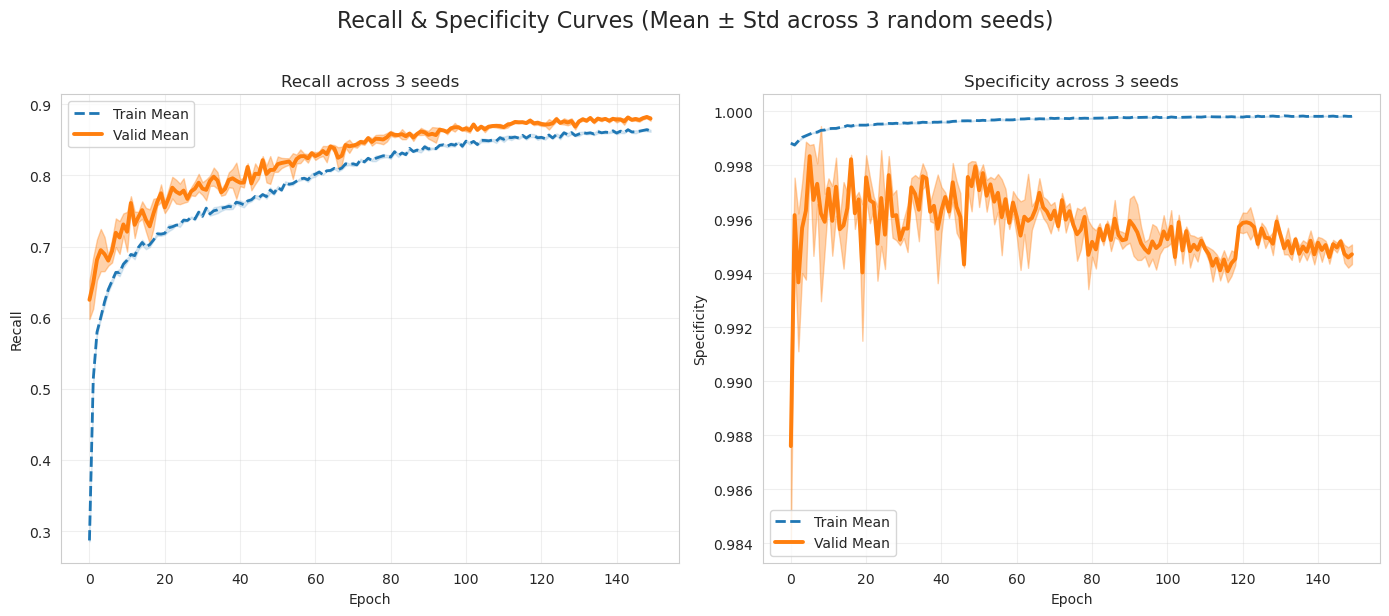

In [24]:
# 准备数据列表
seed_data = [
    {'train': train_13,   'valid': valid_13,   'seed': 13},
    {'train': train_42,   'valid': valid_42,   'seed': 42},
    {'train': train_3407, 'valid': valid_3407, 'seed': 3407}
]

# 调用函数画图（只显示 recall 和 specificity）
plot_recall_specificity_across_seeds(
    seed_data=seed_data,
    figsize=(14, 6),
    save_path='recall_specificity_curves.png'   # 可改成你想要的路径，或设为 None 不保存
)

In [1]:
import numpy as np

In [4]:
a = np.array([2,4,6,8,10])
ids = np.where(a > 5)[0]
ids

array([2, 3, 4])

In [10]:
seq=np.array(list('abcda'))
seq

array(['a', 'b', 'c', 'd', 'a'], dtype='<U1')

In [16]:
oxo=ids[np.where(seq[ids]=='c')[0]]
oxo

array([2])

In [17]:
oxo[oxo>5]

array([], dtype=int64)